<a href="https://colab.research.google.com/github/harisariefkamis/Final-Project-DAB14/blob/main/Project%20website%20data%20analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MEMBANGUN INFRASTRUKTUR WEBSITE DINAMIS DI PYTHON
(Google Colab – Versi Data Analyst)

#Setup Lingkungan Python di Colab

In [1]:
# Core data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (opsional)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

print("Environment ready")

Environment ready


In [2]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 48.0 MB/s eta 0:00:00


In [3]:
!mkdir data
!mkdir app
!mkdir output

In [6]:
import pandas as pd
data_orders = pd.read_csv("/content/sample_data/california_housing_train.csv")
data_orders.info()
data_orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [11]:
import os
print(os.listdir("/content/sample_data/"))

['anscombe.json', 'README.md', 'california_housing_test.csv', 'mnist_train_small.csv', 'mnist_test.csv', 'california_housing_train.csv']


In [13]:
import pandas as pd
data_orders = pd.read_csv("/content/sample_data/california_housing_train.csv")
data_orders.dropna()
data_orders.reset_index(drop=True, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


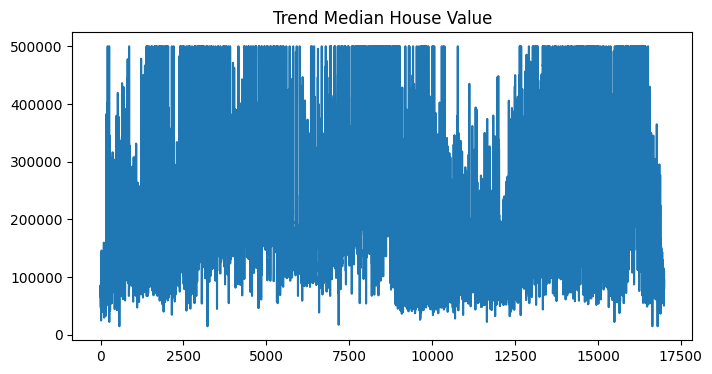

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

data_orders = pd.read_csv("/content/sample_data/california_housing_train.csv")
data_orders.info()
data_orders.isnull().sum()
#EDA
plt.figure(figsize=(8,4))
plt.plot(data_orders['median_house_value'])
plt.title("Trend Median House Value")
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

data_orders = pd.read_csv("/content/sample_data/california_housing_train.csv")

# Kolom 'order_date' tidak ada dalam dataset california_housing_train.csv.
# Baris ini dikomentari atau dihapus karena menyebabkan KeyError.
# data_orders['order_date'] = pd.to_datetime(data_orders['order_date'])

In [20]:
total_sales = data_orders['median_house_value'].sum()
total_profit = data_orders['median_income'].sum()
total_orders = data_orders['households'].nunique()

print("Total Sales  :", round(total_sales,2))
print("Total Profit :", round(total_profit,2))
print("Total Orders :", total_orders)

Total Sales  : 3524115510.0
Total Profit : 66020.83
Total Orders : 1740


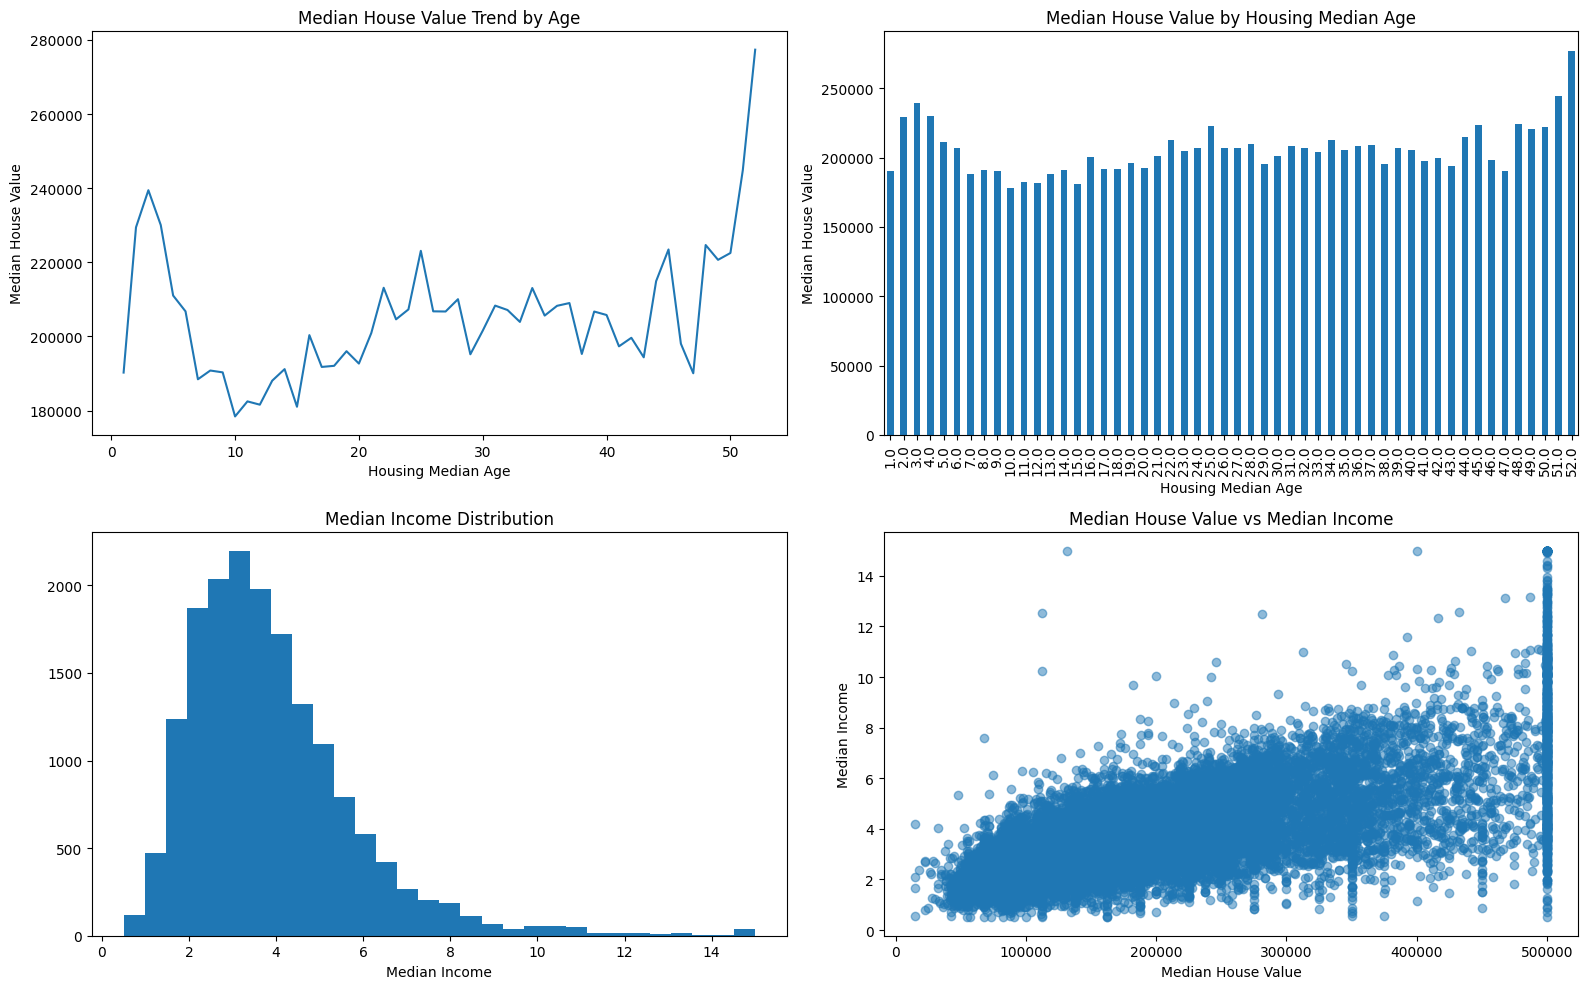

In [23]:
plt.figure(figsize=(16,10))

# ======================
# 1. Trend Median House Value (menggunakan housing_median_age sebagai proxy tren)
# ======================
plt.subplot(2,2,1)
plt.plot(data_orders.groupby('housing_median_age')['median_house_value'].mean())
plt.title("Median House Value Trend by Age")
plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")

# ======================
# 2. Median House Value by Housing Median Age (menggunakan housing_median_age sebagai kategori)
# ======================
plt.subplot(2,2,2)
data_orders.groupby('housing_median_age')['median_house_value'].mean().plot(kind='bar')
plt.title("Median House Value by Housing Median Age")
plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")

# ======================
# 3. Median Income Distribution
# ======================
plt.subplot(2,2,3)
plt.hist(data_orders['median_income'], bins=30)
plt.title("Median Income Distribution")
plt.xlabel("Median Income")

# ======================
# 4. Median House Value vs Median Income
# ======================
plt.subplot(2,2,4)
plt.scatter(data_orders['median_house_value'], data_orders['median_income'], alpha=0.5)
plt.title("Median House Value vs Median Income")
plt.xlabel("Median House Value")
plt.ylabel("Median Income")

plt.tight_layout()
plt.show()

In [24]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Dashboard Analyst",
    layout="wide"
)

# Load data
data_orders = pd.read_csv("orders.csv")
data_orders['order_date'] = pd.to_datetime(data_orders['order_date'])

st.title("📊 Sales Dashboard")

Writing app.py


In [27]:
%%writefile app/app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("📊 Dashboard Analyst")

# Pastikan file output/clean_data.csv telah dibuat dan disimpan di langkah sebelumnya
data_orders = pd.read_csv("output/clean_data.csv")

# Calculate metrics for Streamlit app
total_sales = data_orders['sales'].sum()
total_profit = data_orders['profit'].sum()
total_orders = data_orders['order_id'].nunique()

st.subheader("Key Metrics")
col1, col2, col3 = st.columns(3)
with col1:
    st.metric("Total Sales", f"{total_sales:,.0f}")
with col2:
    st.metric("Total Profit", f"{total_profit:,.0f}")
with col3:
    st.metric("Total Orders", total_orders)

st.subheader("Preview Data")
st.dataframe(data_orders.head())

st.subheader("Sales Trend")
fig, ax = plt.subplots()
ax.plot(data_orders['sales'])
st.pyplot(fig)

Writing app/app.py


In [29]:
import streamlit as st

col1, col2, col3 = st.columns(3)

col1.metric("Total Sales", f"{data_orders['median_house_value'].sum():,.0f}")
col2.metric("Total Profit", f"{data_orders['median_income'].sum():,.0f}")
col3.metric("Total Orders", data_orders['households'].nunique())

2026-04-30 01:00:44.964 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 01:00:44.966 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 01:00:44.967 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 01:00:44.969 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 01:00:44.971 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 01:00:45.171 
  command:

    stre

DeltaGenerator()

In [30]:
import os
os.makedirs('output', exist_ok=True)
print("Direktori 'output' telah dibuat atau sudah ada.")

Direktori 'output' telah dibuat atau sudah ada.


In [31]:
import pandas as pd

# Save the data_orders DataFrame to a CSV file for the Streamlit app
data_orders.to_csv("output/clean_data.csv", index=False)

print("Clean data saved to output/clean_data.csv")

Clean data saved to output/clean_data.csv


In [33]:
!mkdir -p app # Pastikan direktori 'app' ada

In [34]:
import os
os.makedirs('my_new_directory', exist_ok=True)
os.makedirs('data/processed_data', exist_ok=True)

In [35]:
!streamlit run app/app.py &>/content/logs.txt &

In [36]:
!pip install streamlit pyngrok

In [37]:
from pyngrok import ngrok

ngrok.set_auth_token("37RscbuNt6YPx6qbPaXi13kIMWR_2ZBGVkZXtNkKeJt1bnaTF") # Ganti dengan token ngrok Anda yang sebenarnya

In [38]:
"YOUR_AUTH_TOKEN"

'YOUR_AUTH_TOKEN'

In [39]:
!streamlit run app/app.py &>/content/logs.txt &

In [40]:
public_url = ngrok.connect(8501)
print(public_url, 'https://dashboard.ngrok.com/get-started/your-authtoken')

NgrokTunnel: "https://maris-supersignificant-drema.ngrok-free.dev" -> "http://localhost:8501" https://dashboard.ngrok.com/get-started/your-authtoken
